# Logistic Regression

In [1]:
#Importamos Librerias
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
#Leer Datos en formato xlsx
df = pd.read_excel("data.xlsx")
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   y       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [3]:
#Cargar Datos
X = df[["X1","X2"]]
y = df["y"]


In [4]:
#Division 70/30
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [5]:
#Modelo 
modelo = LogisticRegression()
modelo.fit(X_train,y_train)

y_pred = modelo.predict(X_test)

In [6]:
#Métricas
cm = confusion_matrix(y_test,y_pred)
vn,fp,fn,vp = cm.ravel()

sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
precision = vp / (vp + fp)
exactitud = (vp + vn) / (vp + vn + fp + fn)

print("Sensibilidad:", sensibilidad)
print("Especificidad:", especificidad)
print("Precisión:", precision)
print("Exactitud:", exactitud)

Sensibilidad: 0.7986111111111112
Especificidad: 0.34615384615384615
Precisión: 0.5299539170506913
Exactitud: 0.5633333333333334


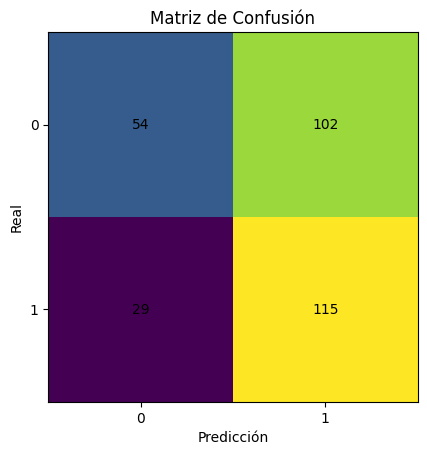

In [7]:
#Matriz de Confusion
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("matriz_confusion.png")
plt.show()

c:\Users\mateo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


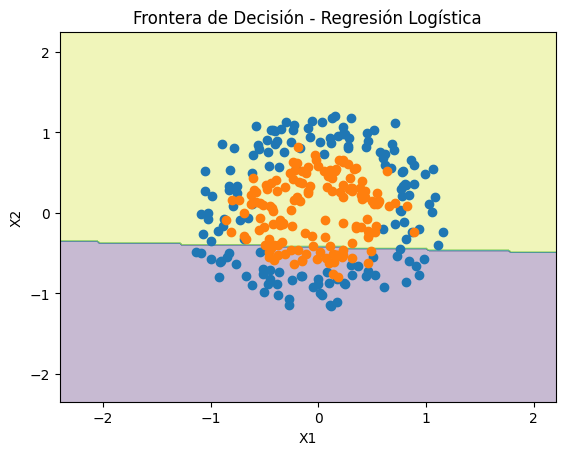

In [8]:
#Frontera de Decision
x_min, x_max = X["X1"].min() - 1, X["X1"].max() + 1
y_min, y_max = X["X2"].min() - 1, X["X2"].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = modelo.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test[y_test == 0]["X1"], X_test[y_test == 0]["X2"])
plt.scatter(X_test[y_test == 1]["X1"], X_test[y_test == 1]["X2"])
plt.title("Frontera de Decisión - Regresión Logística")
plt.xlabel("X1")
plt.ylabel("X2")
plt.savefig("frontera_decision.png")
plt.show()

### INTERPRETACIÓN

En la gráfica, así como en la matriz de confusión podemos ver claramente, como la regresión Logística no clasifica correctamente los datos, ya que son datos mas complejos de separar en clases con solo una linea, cosa que hace la regresión logística